# Basics: what is parameter estimation?

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Google Colab worksheet for early-stage graduate students. Run from top to bottom; **Extension** sections may be skipped live.


## Goal

Parameter estimation (PE) means constructing a probability distribution for unknown parameters after observing data. We will follow the teaching sequence used in the NZ Bilby CBC workshop:

1. write a signal model;
2. choose priors;
3. write a likelihood from a noise assumption;
4. calculate a posterior on a grid;
5. inspect marginals and posterior predictions;
6. replace white noise by a gravitational-wave-style PSD-weighted likelihood.

Bayes' theorem is

\[
p(\theta\mid d,M)=\frac{p(d\mid\theta,M)\,p(\theta\mid M)}{p(d\mid M)}
=\frac{\mathcal L(d\mid\theta)\,\pi(\theta)}{\mathcal Z}.
\]

The evidence $\mathcal Z$ normalises the posterior and compares complete models. PE is not just optimisation: it retains uncertainty, correlations, multiple solutions, and prior dependence.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"
print("Running in Colab:", IN_COLAB)

Running in Colab: False


## 1. Data and a signal model

Assume $d_i=m t_i+c+n_i$ and independent Gaussian noise $n_i\sim\mathcal N(0,\sigma^2)$. Every likelihood statement is conditional on assumptions like these.

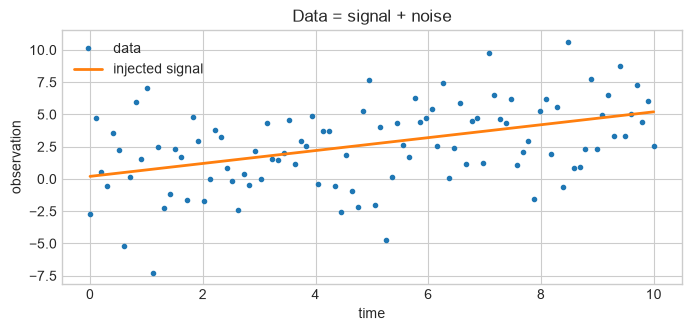

In [2]:
true_parameters={"m":.5,"c":.2}; sigma=3.0
time=np.linspace(0,10,100)
def signal_model(time,m,c): return m*time+c
data=signal_model(time,**true_parameters)+rng.normal(0,sigma,time.size)
fig,ax=plt.subplots(figsize=(8,3.3)); ax.plot(time,data,"o",ms=3,label="data")
ax.plot(time,signal_model(time,**true_parameters),lw=2,label="injected signal")
ax.set(xlabel="time",ylabel="observation",title="Data = signal + noise"); ax.legend(); plt.show()

## 2. Priors and prior predictive checks

Take $m\sim\mathrm{Uniform}(0,1.5)$ and $c\sim\mathrm{Uniform}(-5,5)$. A prior is part of the model, not an afterthought. Drawing curves from it checks whether the model can plausibly describe the data before inference.

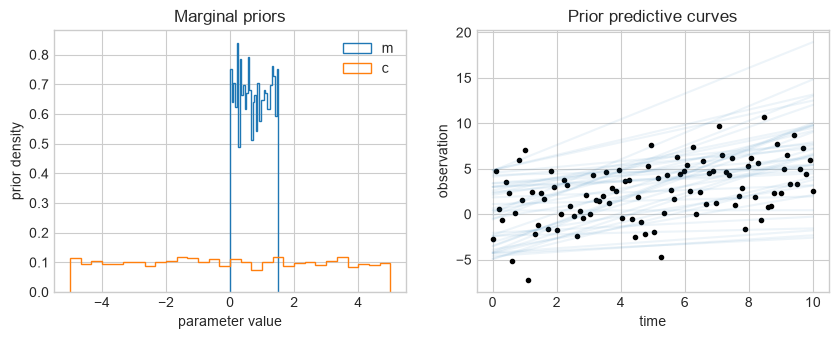

In [3]:
n_prior=2500
prior_m=rng.uniform(0,1.5,n_prior); prior_c=rng.uniform(-5,5,n_prior)
fig,axes=plt.subplots(1,2,figsize=(10,3.4))
axes[0].hist(prior_m,bins=30,density=True,histtype="step",label="m")
axes[0].hist(prior_c,bins=30,density=True,histtype="step",label="c")
axes[0].set(xlabel="parameter value",ylabel="prior density",title="Marginal priors"); axes[0].legend()
axes[1].plot(time,data,"o",ms=3,color="k")
for m,c in zip(prior_m[:40],prior_c[:40]): axes[1].plot(time,signal_model(time,m,c),color="C0",alpha=.08)
axes[1].set(xlabel="time",ylabel="observation",title="Prior predictive curves"); plt.show()

## 3. Gaussian likelihood

\[
\log\mathcal L(d\mid m,c)=-\frac12\sum_i\left[
\frac{(d_i-mt_i-c)^2}{\sigma^2}+\log(2\pi\sigma^2)\right].
\]

Changing the assumed noise scale changes the width of the posterior. If the noise model is wrong, a mathematically correct sampler still gives a misleading answer.

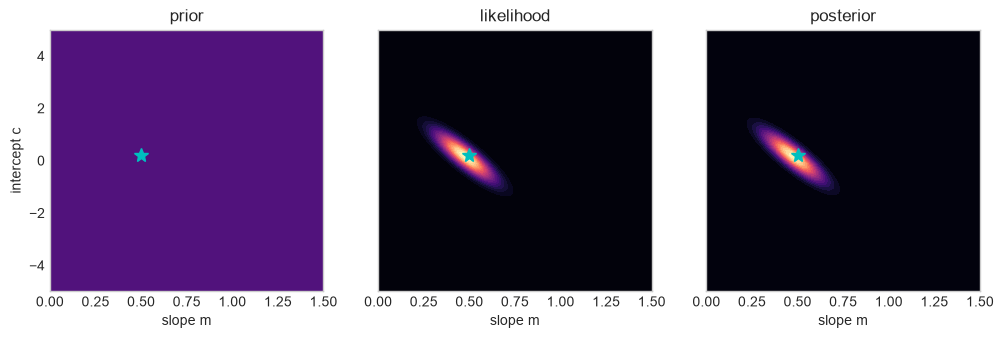

In [4]:
def log_likelihood(m,c):
    residual=data-signal_model(time,m,c)
    return -.5*np.sum((residual/sigma)**2+np.log(2*np.pi*sigma**2))

m_grid=np.linspace(0,1.5,141); c_grid=np.linspace(-5,5,161)
M,C=np.meshgrid(m_grid,c_grid,indexing="ij")
logL=np.array([[log_likelihood(m,c) for c in c_grid] for m in m_grid])
log_prior=np.zeros_like(logL)  # constant inside this finite grid
log_posterior=logL+log_prior
posterior=np.exp(log_posterior-log_posterior.max())
posterior/=np.trapezoid(np.trapezoid(posterior,c_grid,axis=1),m_grid)

fig,axes=plt.subplots(1,3,figsize=(12,3.4),sharex=True,sharey=True)
for ax,values,title in zip(axes,[np.exp(log_prior),np.exp(logL-logL.max()),posterior],["prior","likelihood","posterior"]):
    image=ax.contourf(m_grid,c_grid,values.T,levels=24,cmap="magma")
    ax.plot(true_parameters["m"],true_parameters["c"],"c*",ms=10); ax.set(title=title,xlabel="slope m")
axes[0].set_ylabel("intercept c"); plt.show()

The posterior is a ridge: increasing the slope can be compensated by decreasing the intercept. Marginalisation integrates over the other parameter; it is not the same as holding it at a best-fit value.

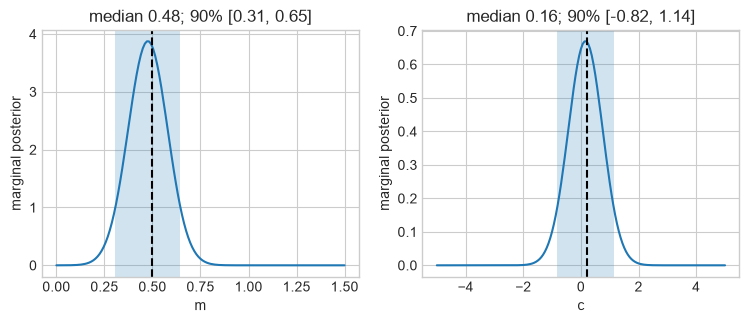

In [5]:
p_m=np.trapezoid(posterior,c_grid,axis=1); p_c=np.trapezoid(posterior,m_grid,axis=0)
def interval(grid,density):
    cdf=np.r_[0,np.cumsum((density[:-1]+density[1:])*np.diff(grid)/2)]; cdf/=cdf[-1]
    return np.interp([.05,.5,.95],cdf,grid)
fig,axes=plt.subplots(1,2,figsize=(9,3.2))
for ax,grid,density,name,truth in zip(axes,[m_grid,c_grid],[p_m,p_c],["m","c"],true_parameters.values()):
    q=interval(grid,density); ax.plot(grid,density); ax.axvline(truth,color="k",ls="--")
    ax.axvspan(q[0],q[2],alpha=.2); ax.set(xlabel=name,ylabel="marginal posterior",title=f"median {q[1]:.2f}; 90% [{q[0]:.2f}, {q[2]:.2f}]")
plt.show()

## 4. Posterior predictive check

Draw parameter pairs from the posterior and map each through the signal model. This asks whether the inferred model can reproduce data like those observed.

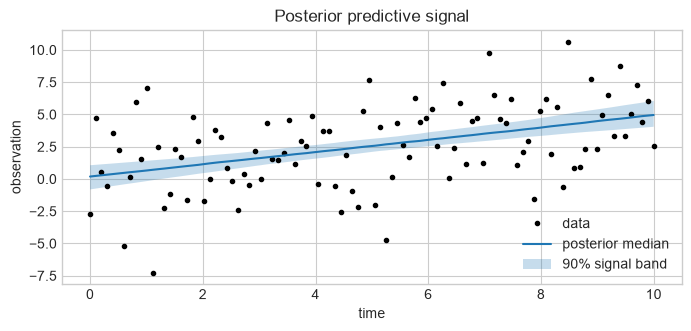

In [6]:
weights=(posterior/posterior.sum()).ravel(); choices=rng.choice(weights.size,size=250,replace=True,p=weights)
m_samples=M.ravel()[choices]; c_samples=C.ravel()[choices]
predictions=np.array([signal_model(time,m,c) for m,c in zip(m_samples,c_samples)])
low,median,high=np.quantile(predictions,[.05,.5,.95],axis=0)
fig,ax=plt.subplots(figsize=(8,3.3)); ax.plot(time,data,"o",ms=3,color="k",label="data")
ax.plot(time,median,label="posterior median"); ax.fill_between(time,low,high,alpha=.25,label="90% signal band")
ax.set(xlabel="time",ylabel="observation",title="Posterior predictive signal"); ax.legend(); plt.show()

## 5. The gravitational-wave bridge: coloured noise

GW detector noise depends strongly on frequency. For approximately stationary Gaussian noise, positive-frequency bins give the Whittle likelihood

\[
\log\mathcal L=-\frac12(d-h\mid d-h)+C,\qquad
(a\mid b)=4\,\mathrm{Re}\sum_k\frac{\tilde a_k\tilde b_k^*}{S_n(f_k)}\Delta f.
\]

$S_n$ is the one-sided power spectral density (PSD); $\sqrt{S_n}$ is the amplitude spectral density (ASD). The PSD decides which residuals matter.

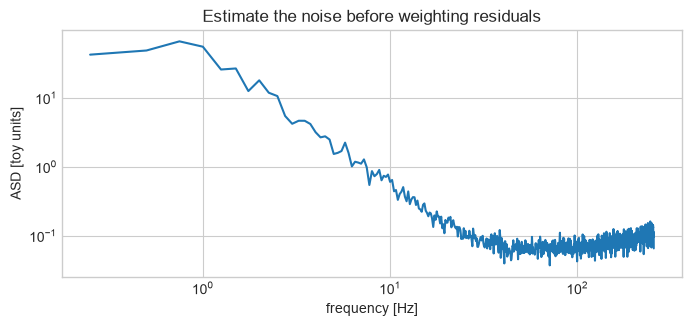

In [7]:
from scipy.signal import welch
sample_rate=512; duration=32; t=np.arange(0,duration,1/sample_rate); f=np.fft.rfftfreq(t.size,1/sample_rate)
shape=1+(30/np.maximum(f,1))**4+(f/180)**2
coloured=np.fft.irfft(np.fft.rfft(rng.normal(size=t.size))*np.sqrt(shape),n=t.size)
f_psd,psd=welch(coloured,fs=sample_rate,nperseg=2048,average="median")
fig,ax=plt.subplots(figsize=(8,3.2)); ax.loglog(f_psd[1:],np.sqrt(psd[1:]))
ax.set(xlabel="frequency [Hz]",ylabel="ASD [toy units]",title="Estimate the noise before weighting residuals"); plt.show()

## Checks and takeaways

1. Widen the prior: which marginal changes most?
2. Halve the assumed `sigma`: does the posterior become more accurate or merely more confident?
3. Why may the likelihood normalisation be dropped for fixed PSD PE but not when comparing noise models?

**Takeaway:** PE is a model–data–noise calculation. A posterior is only as trustworthy as the waveform, response, PSD, priors, and computation that define it.

Adapted from the local `nz_bilby_cbc_workshop_2024` and its source, Colm Talbot's Bayesian inference tutorial.